# Кейс 5. Метрические методы классификации

## 1. Подготовка окружения и импорты


In [1]:
import pathlib
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from sklearn.datasets import load_iris, load_wine, load_breast_cancer, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Подключение локальных модулей
PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from case_5.src.classifiers import KNNClassifier, WeightedKNNClassifier, ParzenFixedClassifier, ParzenVariableClassifier
from case_5.src.selection import compactness_profile, select_prototypes_addition
from shared.validation import leave_one_out_classification

import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black"
})

## 2. Загрузка данных и проверка масштабирования

In [3]:
wine = load_wine()
X_train, X_test, y_train, y_test = train_test_split(wine.data, wine.target, test_size=0.3, random_state=42)

model_unscaled = KNNClassifier(k=1).fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, model_unscaled.predict(X_test))

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = KNNClassifier(k=1).fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, model_scaled.predict(X_test_scaled))

# Создаем таблицу с помощью DataFrame
results_df = pd.DataFrame({
    "Состояние данных": ["Без масштабирования", "С масштабированием (StandardScaler)"],
    "Accuracy (1NN)": [acc_unscaled, acc_scaled]
})

display(HTML("<h3>Влияние масштабирования на датасете Wine</h3>"))
display(results_df.style.format({"Accuracy (1NN)": "{:.4f}"}).hide(axis="index"))

Состояние данных,Accuracy (1NN)
Без масштабирования,0.7963
С масштабированием (StandardScaler),0.9630


## 3. Карты классификации и границы решений (Синтетические данные)

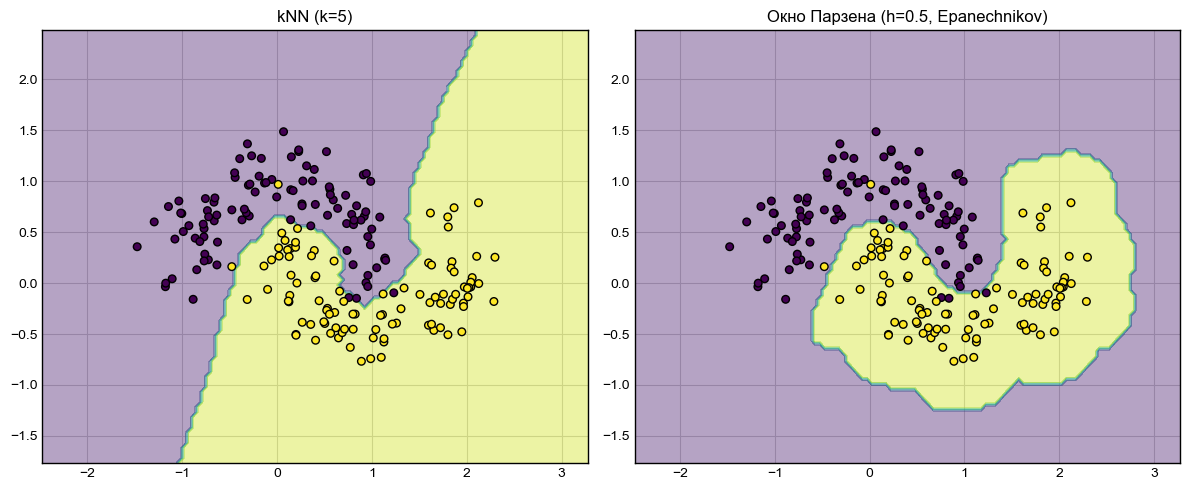

In [4]:
def plot_decision_boundary(model, X, y, title):
    h = .05
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolor='k', cmap='viridis')
    plt.title(title)

X_syn, y_syn = make_moons(n_samples=200, noise=0.2, random_state=42)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(KNNClassifier(k=5).fit(X_syn, y_syn), X_syn, y_syn, "kNN (k=5)")

plt.subplot(1, 2, 2)
plot_decision_boundary(ParzenFixedClassifier(h=0.5, kernel='epanechnikov').fit(X_syn, y_syn), X_syn, y_syn, "Окно Парзена (h=0.5, Epanechnikov)")
plt.tight_layout()
plt.show()

### Сравним ParzenFixedClassifier и ParzenVariableClassifier отдельно

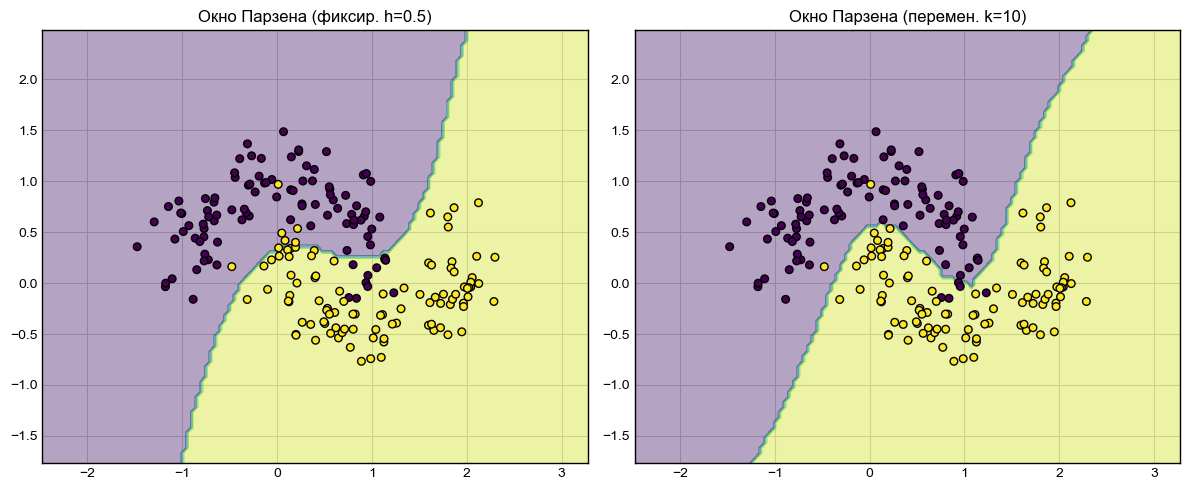

In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(ParzenFixedClassifier(h=0.5, kernel='gaussian').fit(X_syn, y_syn),
                       X_syn, y_syn, "Окно Парзена (фиксир. h=0.5)")

plt.subplot(1, 2, 2)
plot_decision_boundary(ParzenVariableClassifier(k=10, kernel='gaussian').fit(X_syn, y_syn),
                       X_syn, y_syn, "Окно Парзена (перемен. k=10)")
plt.tight_layout()
plt.show()

## 4. LOO-ошибка от параметров (k, h, p) и вида ядра K на датасете Iris

In [6]:
X_iris_scaled = StandardScaler().fit_transform(load_iris().data)
y_iris = load_iris().target

### kNN:

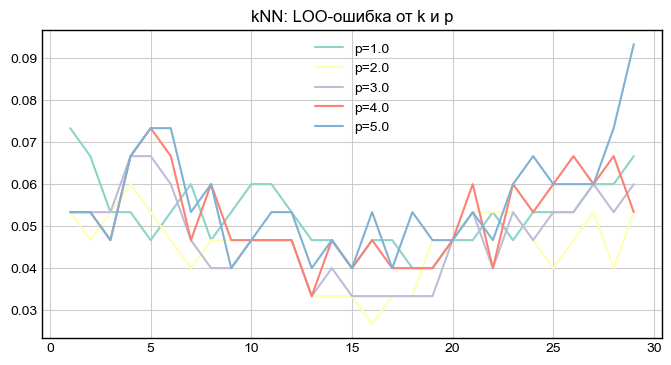

In [7]:
# kNN: Подбор k и p
k_range = range(1, 30)
p_range = np.linspace(1, 5, 5)

# Перебор параметров
results_knn =[]
for p in p_range:
    for k in k_range:
        err = leave_one_out_classification(KNNClassifier(k=k, p=p), X_iris_scaled, y_iris)
        results_knn.append({'k': k, 'p': p, 'err': err})

df_knn = pd.DataFrame(results_knn)
best_knn = df_knn.loc[df_knn['err'].idxmin()]

plt.figure(figsize=(8, 4))
for p in p_range:
    subset = df_knn[df_knn['p'] == p]
    plt.plot(subset['k'], subset['err'], label=f'p={p:.1f}')
plt.title("kNN: LOO-ошибка от k и p")
plt.legend(); plt.show()

display(HTML(f"<b>Лучший kNN:</b> k={int(best_knn['k'])}, p={best_knn['p']:.1f} (Ошибка: {best_knn['err']:.4f})"))

In [8]:
kernels = ['gaussian', 'triangular', 'epanechnikov', 'quartic', 'uniform']

### Parzen Fixed:

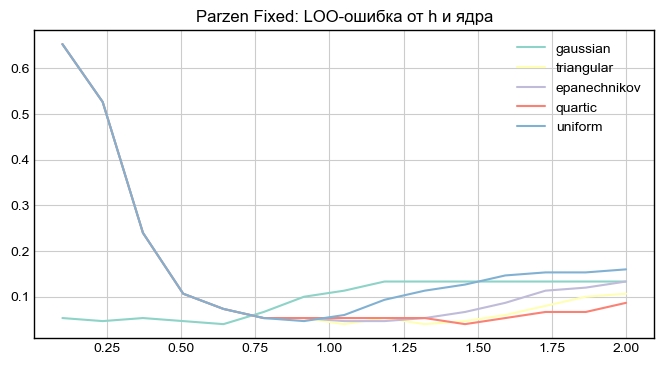

In [9]:
h_range = np.linspace(0.1, 2.0, 15)

results_pf =[]
for ker in kernels:
    for h in h_range:
        err = leave_one_out_classification(ParzenFixedClassifier(h=h, kernel=ker), X_iris_scaled, y_iris)
        results_pf.append({'h': h, 'kernel': ker, 'err': err})

df_pf = pd.DataFrame(results_pf)
best_pf = df_pf.loc[df_pf['err'].idxmin()]

plt.figure(figsize=(8, 4))
for ker in kernels:
    subset = df_pf[df_pf['kernel'] == ker]
    plt.plot(subset['h'], subset['err'], label=ker)
plt.title("Parzen Fixed: LOO-ошибка от h и ядра")
plt.legend(); plt.show()

display(HTML(f"<b>Лучший Parzen Fixed:</b> h={best_pf['h']:.2f}, Kernel={best_pf['kernel']} (Ошибка: {best_pf['err']:.4f})"))

### Parzen Variable:

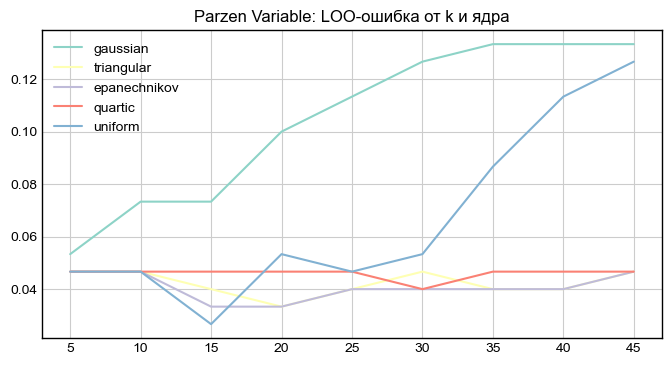

In [10]:
k_var_range = range(5, 50, 5)

results_pv =[]
for ker in kernels:
    for k in k_var_range:
        err = leave_one_out_classification(ParzenVariableClassifier(k=k, kernel=ker), X_iris_scaled, y_iris)
        results_pv.append({'k': k, 'kernel': ker, 'err': err})

df_pv = pd.DataFrame(results_pv)
best_pv = df_pv.loc[df_pv['err'].idxmin()]

plt.figure(figsize=(8, 4))
for ker in kernels:
    subset = df_pv[df_pv['kernel'] == ker]
    plt.plot(subset['k'], subset['err'], label=ker)
plt.title("Parzen Variable: LOO-ошибка от k и ядра")
plt.legend(); plt.show()

display(HTML(f"<b>Лучший Parzen Variable:</b> k={int(best_pv['k'])}, Kernel={best_pv['kernel']} (Ошибка: {best_pv['err']:.4f})"))

## 5. Устойчивость weighted-kNN vs обычный kNN

In [11]:
cancer = load_breast_cancer()
X_canc = StandardScaler().fit_transform(cancer.data)
y_canc = cancer.target

# Инвертируем метки у 10% данных
np.random.seed(42)
noise_idx = np.random.choice(len(y_canc), size=int(0.1 * len(y_canc)), replace=False)
y_canc_noisy = y_canc.copy()
y_canc_noisy[noise_idx] = 1 - y_canc_noisy[noise_idx]

err_knn = leave_one_out_classification(KNNClassifier(k=10), X_canc, y_canc_noisy)
err_wknn = leave_one_out_classification(WeightedKNNClassifier(k=10), X_canc, y_canc_noisy)

df_noise = pd.DataFrame({
    "Модель (k=10)": ["Обычный kNN", "Взвешенный kNN (Weighted)"],
    "LOO Ошибка на зашумленных данных": [err_knn, err_wknn]
})

display(HTML("<h3>Устойчивость алгоритмов к выбросам</h3>"))
display(df_noise.style.format({"LOO Ошибка на зашумленных данных": "{:.4f}"}).hide(axis="index"))

Модель (k=10),LOO Ошибка на зашумленных данных
Обычный kNN,0.1265
Взвешенный kNN (Weighted),0.1195


## 6. Профиль компактности и Отбор эталонов

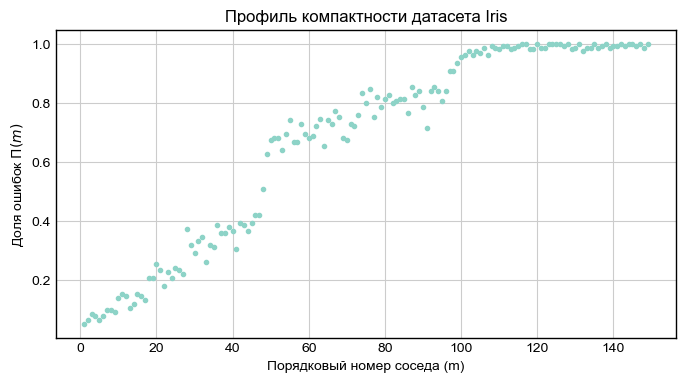

Набор данных,Размер (объектов),Ошибка предсказания,Время предсказания (сек)
Полный датасет,150,0.0533,0.006540
Отобранные эталоны,24,0.0000,0.002554


In [12]:
# 1. Профиль компактности
profile = compactness_profile(X_iris_scaled, y_iris)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(profile)+1), profile, marker='.', linestyle='none')
plt.title("Профиль компактности датасета Iris")
plt.xlabel("Порядковый номер соседа (m)")
plt.ylabel("Доля ошибок $\Pi(m)$")
plt.grid(True)
plt.show()

# 2. Жадный отбор
start_time = time.time()
prototypes_idx = select_prototypes_addition(X_iris_scaled, y_iris)
X_proto, y_proto = X_iris_scaled[prototypes_idx], y_iris[prototypes_idx]

# Сравнение по времени
full_1nn = KNNClassifier(k=1).fit(X_iris_scaled, y_iris)
t0 = time.time()
full_1nn.predict(X_iris_scaled)
time_full = time.time() - t0

proto_1nn = KNNClassifier(k=1).fit(X_proto, y_proto)
t0 = time.time()
proto_1nn.predict(X_iris_scaled)
time_proto = time.time() - t0

err_full = leave_one_out_classification(KNNClassifier(k=1), X_iris_scaled, y_iris)
acc_proto = accuracy_score(y_iris, proto_1nn.predict(X_iris_scaled))

df_stolp = pd.DataFrame({
    "Набор данных": ["Полный датасет", "Отобранные эталоны"],
    "Размер (объектов)": [len(X_iris_scaled), len(prototypes_idx)],
    "Ошибка предсказания": [err_full, 1 - acc_proto],
    "Время предсказания (сек)": [time_full, time_proto]
})

display(HTML("<h3>Эффективность отбора эталонов</h3>"))
display(df_stolp.style.format({
    "Ошибка предсказания": "{:.4f}",
    "Время предсказания (сек)": "{:.6f}"
}).hide(axis="index"))